# Análisis de evaluación de SSGrad-CAM++

Analiza `results/ssgradcampp/eval_metrics.csv` (8051 objetos, conjunto de validación completo de KITTI).

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "pyproject.toml").exists(), f"Unexpected repo root: {REPO_ROOT}"

sys.path.insert(0, str(REPO_ROOT / "src"))
from xai_benchmark.xai.common import unletterbox_map

METRICS = ["pointing_game", "ebpg", "sparseness", "deletion_auc", "insertion_auc"]

Cargamos `eval_metrics.csv`. Se comprueba que las 5 métricas no tengan nulos inesperados.

In [6]:
df = pd.read_csv(REPO_ROOT / "results/ssgradcampp/eval_metrics.csv", dtype={"image_id": str})

print(f"Objetos: {df.shape[0]}, columnas: {df.shape[1]}")
df[METRICS].isna().sum().rename("nulos")

Objetos: 8051, columnas: 14


pointing_game    0
ebpg             0
sparseness       0
deletion_auc     0
insertion_auc    0
Name: nulos, dtype: int64

Calculamos media, mediana y desviación de las 5 métricas sobre todos los objetos juntos. Referencia rápida antes de desglosar por clase/tamaño/corrección.

In [7]:
df[METRICS].agg(["mean", "median", "std"]).T

,mean,median,std
pointing_game,0.999255,1.000000,0.027291
ebpg,0.906649,0.968225,0.126131
sparseness,0.996983,0.998733,0.003207
deletion_auc,0.308387,0.333675,0.214663
insertion_auc,0.629624,0.681981,0.234753


**Desglose por clase:** Media por `pred_class_name`, con el número de objetos al lado. Necesario porque KITTI está
desbalanceado. Misma lógica que ya se usa para mAP y TTA/UQ.

In [8]:
per_class = df.groupby("pred_class_name")[METRICS].mean()
per_class["n_objetos"] = df.groupby("pred_class_name").size()
per_class.sort_values("n_objetos", ascending=False)

,pointing_game,ebpg,sparseness,deletion_auc,insertion_auc,n_objetos
pred_class_name,,,,,,
car,0.999658,0.909642,0.997081,0.359340,0.708315,5855
pedestrian,0.998691,0.887836,0.997188,0.178741,0.350274,764
van,1.000000,0.906917,0.996423,0.178431,0.474276,537
cyclist,0.990566,0.868546,0.997230,0.072297,0.374119,318
truck,1.000000,0.925378,0.996310,0.251268,0.534250,224
misc,1.000000,0.906035,0.996144,0.171700,0.451118,203
tram,1.000000,0.929590,0.995551,0.198372,0.506453,123
person_sitting,1.000000,0.978258,0.996475,0.295638,0.263150,27


**Desglose por `correctness`:**
`correctness` viene del emparejamiento contra el GT (mismo criterio que en TTA/UQ): `correct`,
`wrong_class` o `false_positive` (sin GT que emparejar).

In [9]:
per_correctness = df.groupby("correctness")[METRICS].mean()
per_correctness["n_objetos"] = df.groupby("correctness").size()
per_correctness

,pointing_game,ebpg,sparseness,deletion_auc,insertion_auc,n_objetos
correctness,,,,,,
correct,0.999712,0.920333,0.996837,0.325283,0.660325,6935
false_positive,0.996209,0.818567,0.997980,0.205583,0.441149,1055
wrong_class,1.000000,0.874313,0.996245,0.165452,0.398859,61


**Desglose por tamaño de objeto (K-Means):**

El área no está en `eval_metrics.csv`(solo guarda métricas), así que se recupera de `object_level.csv` por `(image_id, obj_idx)`.
`validate="one_to_one"` obliga a que el cruce sea 1:1.

K-Means con `k=3` sobre el área de la caja.
K-Means no garantiza que la etiqueta `0` sea la del área media más pequeña así que se reordenan por área media y se
remapean a pequeño/mediano/grande. `random_state=0` fija la semilla y `n_init=10` fuerza varias inicializaciones de 
centroides para no depender de un único arranque.

In [14]:
from sklearn.cluster import KMeans

obj_level = pd.read_csv(REPO_ROOT / "results/ssgradcampp/object_level.csv", dtype={"image_id": str})
boxes = obj_level[["image_id", "obj_idx", "x1", "y1", "x2", "y2", "letterbox_h", "letterbox_w"]]

df_boxes = df.merge(boxes, on=["image_id", "obj_idx"], how="left", validate="one_to_one")
assert df_boxes[["x1", "y1", "x2", "y2"]].isna().sum().sum() == 0
df_boxes["area"] = (df_boxes["x2"] - df_boxes["x1"]) * (df_boxes["y2"] - df_boxes["y1"])

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10).fit(df_boxes[["area"]].to_numpy())

mean_area_per_label = df_boxes["area"].groupby(kmeans.labels_).mean()
label_order = mean_area_per_label.sort_values().index.tolist()
size_names = {label_order[0]: "pequeño", label_order[1]: "mediano", label_order[2]: "grande"}
df_boxes["size_bin"] = [size_names[label] for label in kmeans.labels_]

BIN_ORDER = ["pequeño", "mediano", "grande"]
print(df_boxes.groupby("size_bin")["area"].agg(["count", "mean", "min", "max"]).loc[BIN_ORDER])

          count          mean           min            max
size_bin                                                  
pequeño    6742   4367.588008    123.665676   19000.608658
mediano     965  33667.632434  19101.417532   56443.665449
grande      344  79168.052878  56613.629641  193077.484886


In [15]:
per_size = df_boxes.groupby("size_bin")[METRICS].mean().loc[BIN_ORDER]
per_size["n_objetos"] = df_boxes.groupby("size_bin").size().loc[BIN_ORDER]
per_size

,pointing_game,ebpg,sparseness,deletion_auc,insertion_auc,n_objetos
size_bin,,,,,,
pequeño,0.99911,0.890158,0.997816,0.270892,0.597794,6742
mediano,1.00000,0.990156,0.994972,0.503662,0.781780,965
grande,1.00000,0.995608,0.986288,0.495450,0.826611,344


Correlación de Pearson simple entre las métricas de localización (`pointing_game`, `ebpg`) y las de fidelidad (`deletion_auc`, `insertion_auc`).

,pointing_game,ebpg,sparseness,deletion_auc,insertion_auc
pointing_game,1.000000,0.130069,-0.014910,0.035266,0.047379
ebpg,0.130069,1.000000,-0.160135,0.450363,0.363256
sparseness,-0.014910,-0.160135,1.000000,-0.239320,-0.258064
deletion_auc,0.035266,0.450363,-0.239320,1.000000,0.644571
insertion_auc,0.047379,0.363256,-0.258064,0.644571,1.000000


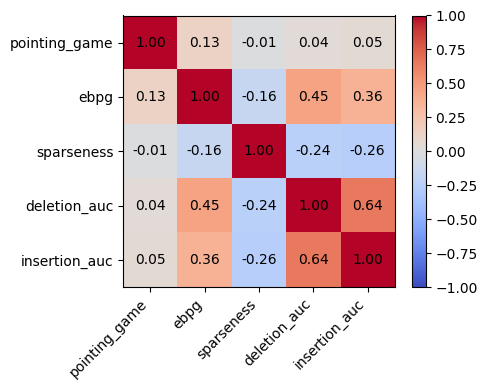

In [11]:
corr = df[METRICS].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(METRICS))); ax.set_xticklabels(METRICS, rotation=45, ha="right")
ax.set_yticks(range(len(METRICS))); ax.set_yticklabels(METRICS)
for i in range(len(METRICS)):
    for j in range(len(METRICS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im)
fig.tight_layout()
corr

Correlación de Pearson entre confidence (paso 0 de la curva) y cada AUC:
deletion_auc     0.375848
insertion_auc    0.610846
Name: confidence, dtype: float64


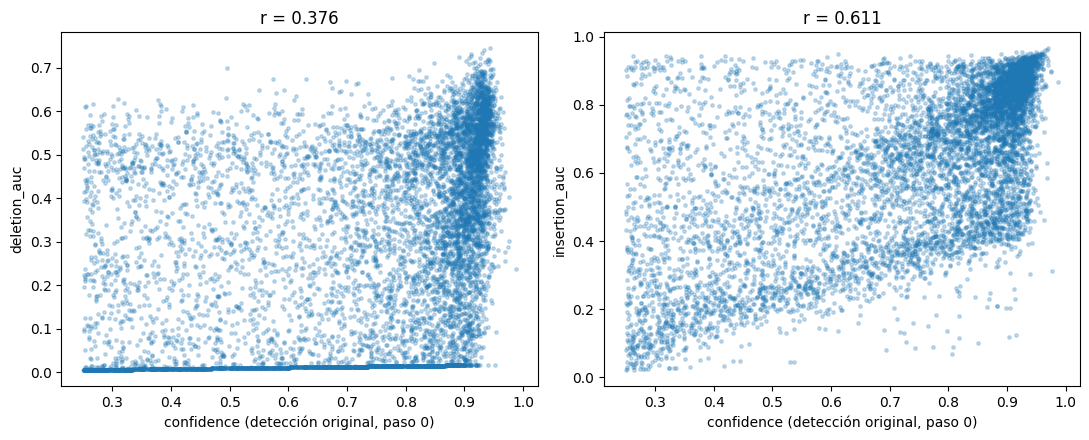

In [19]:
conf = pd.read_csv(REPO_ROOT / "results/ssgradcampp/object_level.csv", dtype={"image_id": str})[
    ["image_id", "obj_idx", "confidence"]
]
df_conf = df.merge(conf, on=["image_id", "obj_idx"], how="left", validate="one_to_one")
assert df_conf["confidence"].isna().sum() == 0

corr_conf = df_conf[["confidence", "deletion_auc", "insertion_auc"]].corr().loc["confidence", ["deletion_auc", "insertion_auc"]]
print("Correlación de Pearson entre confidence (paso 0 de la curva) y cada AUC:")
print(corr_conf)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metric in zip(axes, ["deletion_auc", "insertion_auc"]):
    ax.scatter(df_conf["confidence"], df_conf[metric], s=6, alpha=0.25)
    ax.set_xlabel("confidence (detección original, paso 0)")
    ax.set_ylabel(metric)
    ax.set_title(f"r = {corr_conf[metric]:.3f}")
fig.tight_layout()

**Cruce con incertidumbre TTA/UQ:**

Ambos runs comparten checkpoint y los mismos `conf_thres`/`iou_thres_nms`, así que la
enumeración de objetos por imagen debería coincidir, lo verifico explícitamente comparando
`pred_class` de ambas fuentes tras el cruce, en vez de asumirlo.

In [ ]:
tta = pd.read_csv(REPO_ROOT / "results/tta_uq/object_level.csv", dtype={"image_id": str})
tta = tta.rename(columns={"object_idx": "obj_idx"})
tta_unc = tta[["image_id", "obj_idx", "pred_class", "comp_class_uncertainty", "comp_localization_uncertainty"]]

df_tta = df.merge(tta_unc, on=["image_id", "obj_idx"], how="inner", suffixes=("", "_tta"),
                   validate="one_to_one")
mismatch_rate = (df_tta["pred_class"] != df_tta["pred_class_tta"]).mean()
print(f"Objetos cruzados: {len(df_tta)}/{len(df)}. Desacuerdo de pred_class: {mismatch_rate:.2%}")
assert mismatch_rate < 0.01, "la enumeracion obj_idx no coincide entre ambos runs"

unc_cols = ["comp_class_uncertainty", "comp_localization_uncertainty"]
df_tta[METRICS + unc_cols].corr().loc[METRICS, unc_cols]

Objetos cruzados: 8051/8051. Desacuerdo de pred_class: 0.00%


,comp_class_uncertainty,comp_localization_uncertainty
pointing_game,-0.007642,0.066956
ebpg,-0.039029,0.204892
sparseness,-0.014901,-0.082302
deletion_auc,-0.180002,0.138182
insertion_auc,-0.230062,0.246939


**Desglose por incertidumbre (K-Means)**

In [18]:
for unc_col in ["comp_class_uncertainty", "comp_localization_uncertainty"]:
    X = df_tta[[unc_col]].to_numpy()
    kmeans_unc = KMeans(n_clusters=3, random_state=0, n_init=10).fit(X)

    mean_per_label = df_tta[unc_col].groupby(kmeans_unc.labels_).mean()
    order = mean_per_label.sort_values().index.tolist()
    names = {order[0]: "baja", order[1]: "media", order[2]: "alta"}
    bin_col = f"{unc_col}_bin"
    df_tta[bin_col] = [names[l] for l in kmeans_unc.labels_]

    stats = df_tta.groupby(bin_col, observed=True)[unc_col].agg(["count", "mean", "min", "max"])
    table = df_tta.groupby(bin_col, observed=True)[METRICS].mean()
    table["n_objetos"] = df_tta.groupby(bin_col, observed=True).size()
    print(f"--- {unc_col} ---")
    print(stats.loc[["baja", "media", "alta"]])
    print(table.loc[["baja", "media", "alta"]])
    print()

--- comp_class_uncertainty ---
                            count      mean           min       max
comp_class_uncertainty_bin                                         
baja                         7194  0.013544  5.156676e-08  0.148174
media                         471  0.283691  1.489730e-01  0.455024
alta                          386  0.630957  4.571395e-01  1.363580
                            pointing_game      ebpg  sparseness  deletion_auc  \
comp_class_uncertainty_bin                                                      
baja                             0.999444  0.908340    0.996999      0.319278   
media                            0.995754  0.879468    0.997060      0.224104   
alta                             1.000000  0.908298    0.996586      0.208246   

                            insertion_auc  n_objetos  
comp_class_uncertainty_bin                            
baja                             0.644844       7194  
media                            0.507852        471  
alt

## Conclusiones

**Estadísticos globales.** Sin nulos en ninguna de las 5 métricas sobre los 8051
objetos. La localización está prácticamente saturada: `pointing_game` (media 0.999) y `ebpg`
(media 0.907, mediana 0.968) indican que el pico y la masa del heatmap caen casi siempre dentro
de la caja del objetivo. La fidelidad tiene mucho más recorrido y es la que realmente distingue
objetos: `deletion_auc` (media 0.308, bajo es mejor) e `insertion_auc` (media 0.630, alto es
mejor) con desviaciones de ~0.21-0.23, frente a una desviación de solo 0.03 en `pointing_game`.

**Por clase.** En `ebpg` e `insertion_auc` sí
se repite el patrón ya visto en detección y en TTA/UQ:
`truck`/`tram`/`car` explican mejor que `cyclist`/`pedestrian`/`person_sitting`. Pero en
`deletion_auc` el patrón se **invierte**: `car` (la clase más numerosa y mejor detectada) tiene
el `deletion_auc` más alto de todas (0.359, peor por convención), mientras que `cyclist` tiene el
más bajo (0.072, el mejor). No es un error de cálculo: es la misma consecuencia de que
`deletion_auc` esté anclado por la confianza de partida de la detección (ver más abajo) — `car`
tiende a detectarse con más confianza, lo que infla mecánicamente su curva de Deletion entera,
con independencia de si el heatmap es mejor o peor.

**Por `correctness`.** Aquí sí es consistente: las detecciones `correct`
tienen mejor `ebpg` (0.920) e `insertion_auc` (0.660) que `false_positive` (0.819 / 0.441) y
`wrong_class` (0.874 / 0.399) — una detección ya errónea viene acompañada de una explicación
menos fiel, no solo peor clasificada. `deletion_auc` vuelve a mostrar el patrón invertido
(`wrong_class`=0.165 es el "mejor", `correct`=0.325 el "peor"), coherente con el mismo efecto de
confianza de partida: los falsos positivos/clase incorrecta parten de menos confianza.

**Por tamaño de objeto (K-Means sobre área).** Mismo patrón que
por clase: `ebpg` (0.890→0.990→0.996) e `insertion_auc` (0.598→0.782→0.827) mejoran con claridad
de objetos pequeños a grandes, mientras que `deletion_auc` empeora en la misma dirección
(0.271→0.504→0.496) — otra vez el efecto de confianza de partida, ya que los objetos grandes
suelen detectarse con más confianza.

**Relación entre métricas.** La correlación de Pearson global (sin agrupar) muestra que 
`deletion_auc` e `insertion_auc` concuerdan razonablemente objeto a objeto (r=0.64) y que 
`ebpg` correlaciona moderadamente con ambas (0.45 y 0.36). A nivel de objeto individual, 
las métricas de localización y fidelidad apuntan en general en la misma dirección. 
Las inversiones que aparecen por clase/corrección/ tamaño no contradicen esto: son un efecto 
de comparar medias de grupos que difieren sistemáticamente en la confianza de partida de la detección, 
(confirmado aparte: la confianza original de la 
detección correlaciona +0.376 con `deletion_auc` y +0.611 con `insertion_auc` — ambas AUC suben con 
más confianza de partida, solo que "subir" es "peor" para Deletion y "mejor" para Insertion).

**Cruce con incertidumbre TTA/UQ.** Las correlaciones directas son débiles (|r|<0.25) para
ambas incertidumbres. El desglose por K-Means sí revela un patrón monótono en
`comp_class_uncertainty`: `deletion_auc` (0.319→0.224→0.208) e `insertion_auc`
(0.645→0.508→0.495) bajan juntas de incertidumbre baja a alta — coherente con el mismo efecto de
confianza. `comp_localization_
uncertainty` no muestra tendencia clara, salvo un hallazgo llamativo sin explicación cerrada: el
grupo con incertidumbre de localización exactamente 0 (n=715, cajas perfectamente estables entre
pasadas de TTA) tiene el `ebpg` (0.808) y el `insertion_auc` (0.391) más bajos de los tres
grupos a investigar más adelante.

**Síntesis.** SSGrad-CAM++ localiza casi siempre bien sobre YOLO26+KITTI
(`pointing_game`/`ebpg` casi saturados). Las detecciones correctas
se explican mejor que los falsos positivos, y el tamaño del objeto también, en la dirección
esperada para `ebpg`/`insertion_auc`. 

**Nota:**El valor absoluto de la métrica Deletion está anclado por la confianza de partida de 
cada detección, lo que puede invertir su lectura al comparar grupos con confianza sistemáticamente distinta.